In [74]:
import numpy as np
import matplotlib.pyplot as plt

from simulator import Scene, gaussian_map, carrier_map, random_dips, beam_intensity, masked_map, rectangle, circle
from simulator.basis import poly_modes
from simulator.sequences import uniform_steps, linear_steps

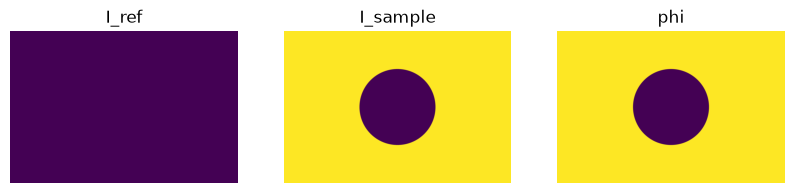

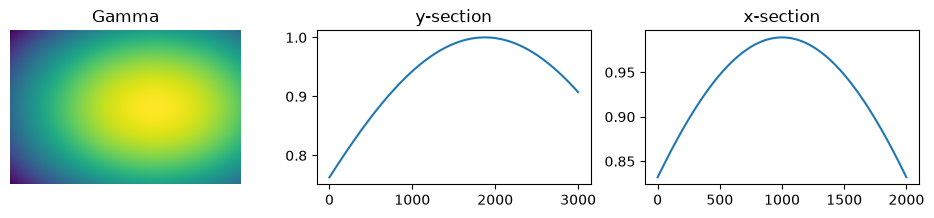

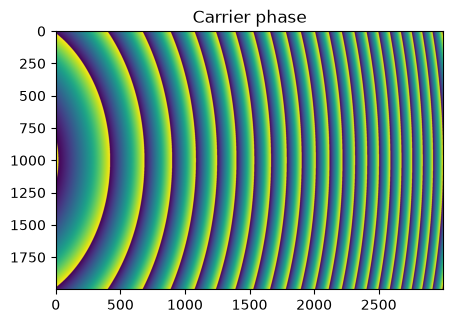

In [75]:
H = 2000 # height in pixels
W = 3000 # width in pixels
N = 10 # number of frames

# Prepare intenisties of the beams and their phase difference
I_ref = masked_map(rectangle(H, W, H//2, W//2), 1.0, 1.0)
I_sample = masked_map(circle(H, W, H//4), 0.7, 1.0)
phi = masked_map(circle(H, W, H//4), 0.5, 1.0) * np.pi

plt.figure(figsize=(10,5))
plt.subplot(131)
plt.title('I_ref')
plt.imshow(I_ref[0])
plt.axis('off')

plt.subplot(132)
plt.title('I_sample')
plt.imshow(I_sample[0])
plt.axis('off')

plt.subplot(133)
plt.title('phi')
plt.imshow(phi[0])
plt.axis('off')

# Setup coherence envelope (gamma)
gamma = gaussian_map(H,W, (2*W,2*H), center=(W//2 + W//8, H//2))

plt.figure(figsize=(12, 2))
plt.subplot(131)
plt.title('Gamma')
plt.imshow(gamma[0])
plt.axis('off')

plt.subplot(132)
plt.title('y-section')
plt.plot(gamma[0,H//2])

plt.subplot(133)
plt.title('x-section')
plt.plot(gamma[0,:,W//2])

# Setup carrier
carrier=[40.0, 0.0, 8.0, 0.0, 2.0]
carrier_2d = carrier_map(H, W, carrier)

plt.figure(figsize=(5,5))
plt.title('Carrier phase')
plt.imshow(np.angle(np.exp(1j*carrier_2d[0])))

In [60]:
# Define piston
piston = uniform_steps(N) 

In [76]:
# Create Scene
scene = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier)
stack = scene.ideal()

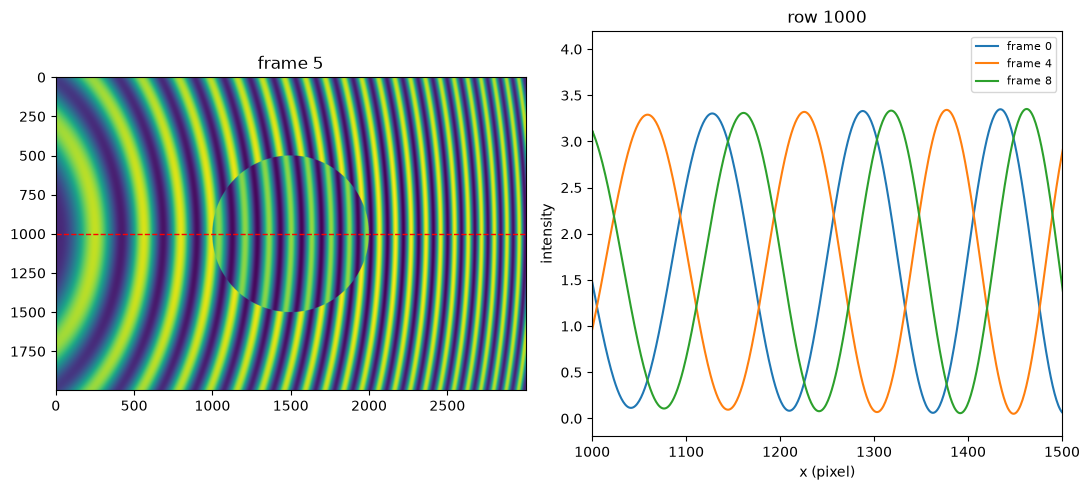

In [77]:
row = stack.shape[1] // 2                  # row for the cross-section
frames = range(0, stack.shape[0], 4)       # frames to overlay, e.g. every 2nd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

ax1.imshow(stack[5])
ax1.axhline(row, color="r", ls="--", lw=1)
ax1.set_title("frame 5")

for n in frames:
    ax2.plot(stack[n, row, :], label=f"frame {n}")
ax2.set_xlabel("x (pixel)")
ax2.set_ylabel("intensity")
ax2.set_title(f"row {row}")
ax2.legend(fontsize=8)
ax2.set_xlim([1000, 1500])

plt.tight_layout()